In [1]:
import os
print(os.getcwd())


C:\Users\ASUS\Desktop\IMD


In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'MAX TEMP.xlsx', 'MaxTempPlot.ipynb']


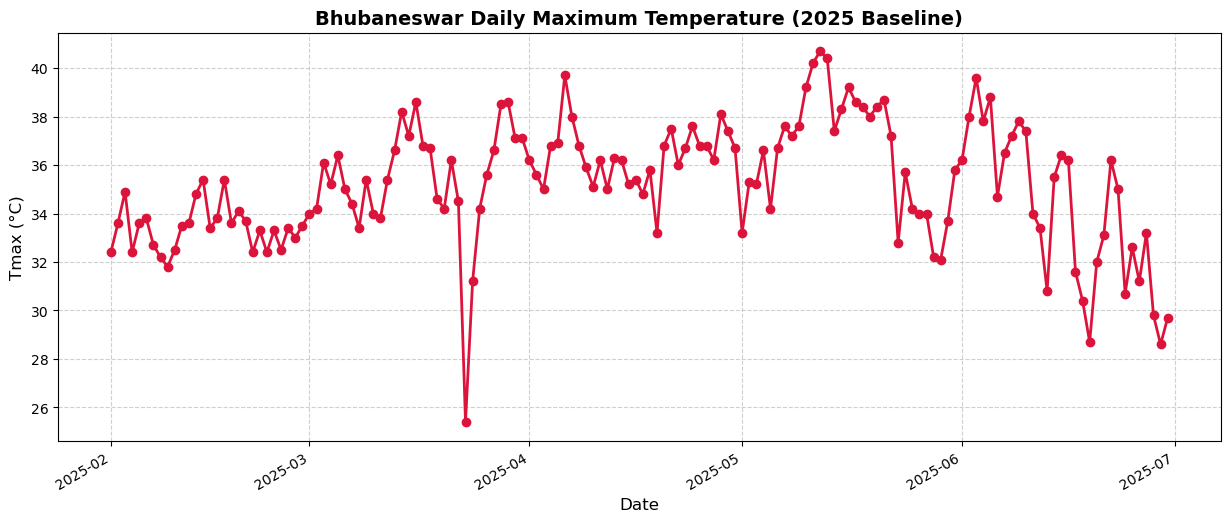

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read the sheet, skipping the first row so row 2 (Index columns) becomes our headers
# We limit nrows=5 to grab just FEB, MAR, APR, MAY, JUN for the 2025 block
df_raw = pd.read_excel("MAX TEMP.xlsx", skiprows=1, nrows=5)

# Rename the first column (which holds the month names) to 'Month'
df_raw = df_raw.rename(columns={df_raw.columns[0]: 'Month'})

# 2. Reshape the table from wide matrix format to long format
# This moves day columns (1, 2, 3...) into a single column called 'Day'
melted = df_raw.melt(id_vars=['Month'], var_name='Day', value_name='Tmax')

# Drop any rows with missing values or invalid days (e.g., empty cells at the end of months)
melted = melted.dropna().copy()

# Ensure the Day column contains integers
melted['Day'] = melted['Day'].astype(int)

# 3. Create a valid datetime column for the year 2025
# Mapping month abbreviations to numbers
month_map = {'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6}
melted['Month_Num'] = melted['Month'].str.strip().str.upper().map(month_map)

# Build a unified string 'YYYY-MM-DD' and convert it to a true datetime object
melted['Date'] = pd.to_datetime(
    '2025-' + melted['Month_Num'].astype(str) + '-' + melted['Day'].astype(str),
    errors='coerce'
)

# Clean up any bad dates (like Feb 30th if it shows up in the grid) and sort chronologically
df_final = melted.dropna(subset=['Date']).sort_values('Date')

# 4. Plotting the parsed data
plt.figure(figsize=(15, 6))
plt.plot(df_final['Date'], df_final['Tmax'], marker='o', color='crimson', linewidth=2)

plt.title("Bhubaneswar Daily Maximum Temperature (2025 Baseline)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Tmax (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gcf().autofmt_xdate() # Auto-rotate date labels for clarity

plt.show()

In [20]:
import os
print(os.getcwd())


C:\Users\ASUS\Desktop


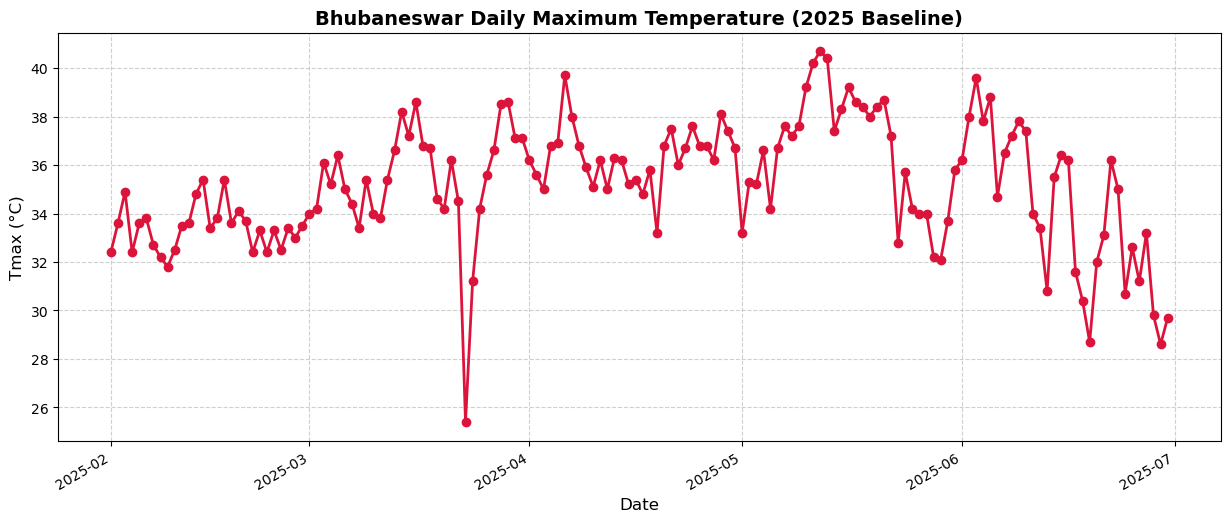

In [6]:
# 1. Read the sheet, skipping the first row so row 2 (Index columns) becomes our headers
# We limit nrows=5 to grab just FEB, MAR, APR, MAY, JUN for the 2025 block
df_raw = pd.read_excel("MAX TEMP.xlsx", skiprows=1, nrows=5)

# Rename the first column (which holds the month names) to 'Month'
df_raw = df_raw.rename(columns={df_raw.columns[0]: 'Month'})

# 2. Reshape the table from wide matrix format to long format
# This moves day columns (1, 2, 3...) into a single column called 'Day'
melted = df_raw.melt(id_vars=['Month'], var_name='Day', value_name='Tmax')

# Drop any rows with missing values or invalid days (e.g., empty cells at the end of months)
melted = melted.dropna().copy()

# Ensure the Day column contains integers
melted['Day'] = melted['Day'].astype(int)

# 3. Create a valid datetime column for the year 2025
# Mapping month abbreviations to numbers
month_map = {'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6}
melted['Month_Num'] = melted['Month'].str.strip().str.upper().map(month_map)

# Build a unified string 'YYYY-MM-DD' and convert it to a true datetime object
melted['Date'] = pd.to_datetime(
    '2025-' + melted['Month_Num'].astype(str) + '-' + melted['Day'].astype(str),
    errors='coerce'
)

# Clean up any bad dates (like Feb 30th if it shows up in the grid) and sort chronologically
df_final = melted.dropna(subset=['Date']).sort_values('Date')

# 4. Plotting the parsed data
plt.figure(figsize=(15, 6))
plt.plot(df_final['Date'], df_final['Tmax'], marker='o', color='crimson', linewidth=2)

plt.title("Bhubaneswar Daily Maximum Temperature (2025 Baseline)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Tmax (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gcf().autofmt_xdate() # Auto-rotate date labels for clarity

plt.show()

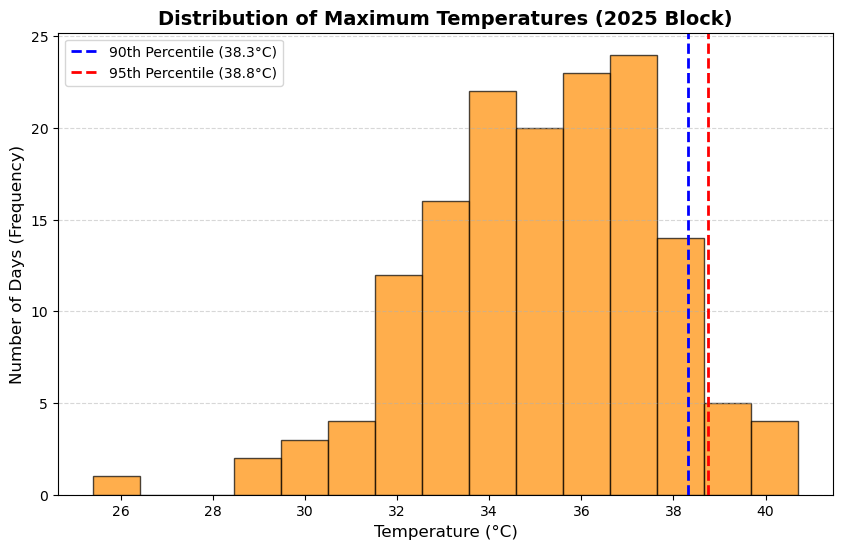

In [9]:
import numpy as np

plt.figure(figsize=(10, 6))
# bins=15 breaks the temperature range into 15 equal intervals
counts, bins, patches = plt.hist(df_final['Tmax'], bins=15, color='darkorange', edgecolor='black', alpha=0.7)

# Optional: Add lines showing where the 90th and 95th percentiles sit on this distribution
p90 = np.percentile(df_final['Tmax'], 90)
p95 = np.percentile(df_final['Tmax'], 95)
plt.axvline(p90, color='blue', linestyle='--', linewidth=2, label=f'90th Percentile ({p90:.1f}°C)')
plt.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'95th Percentile ({p95:.1f}°C)')

plt.title("Distribution of Maximum Temperatures (2025 Block)", fontsize=14, fontweight='bold')
plt.xlabel("Temperature (°C)", fontsize=12)
plt.ylabel("Number of Days (Frequency)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

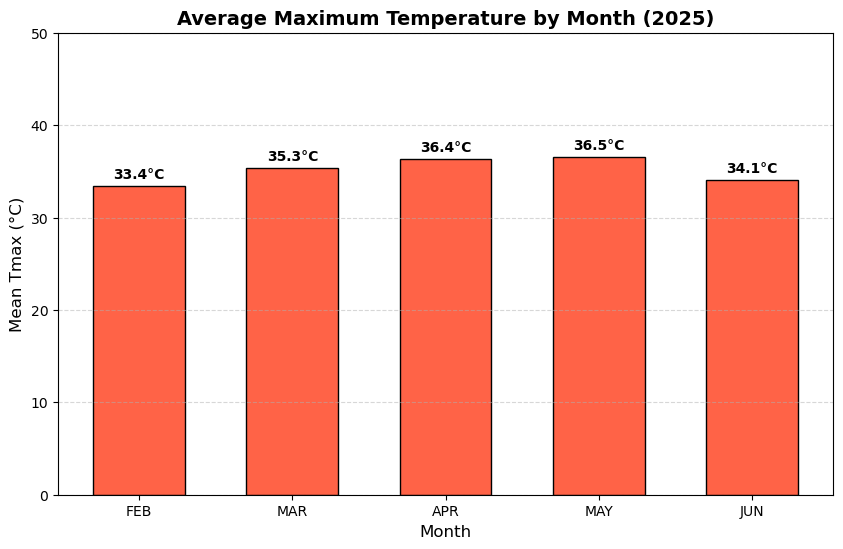

In [7]:
# Group the parsed data by month and calculate the mean for each month
monthly_avg = df_final.groupby('Month')['Tmax'].mean().reindex(['FEB', 'MAR', 'APR', 'MAY', 'JUN'])

plt.figure(figsize=(10, 6))
# Plotting the months on X-axis and their average Tmax on Y-axis
bars = plt.bar(monthly_avg.index, monthly_avg.values, color='tomato', edgecolor='black', width=0.6)

# Add value labels on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.1f}°C", ha='center', va='bottom', fontweight='bold')

plt.title("Average Maximum Temperature by Month (2025)", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Mean Tmax (°C)", fontsize=12)
plt.ylim(0, 50) # Set Y limit higher than max temp to leave room for labels
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

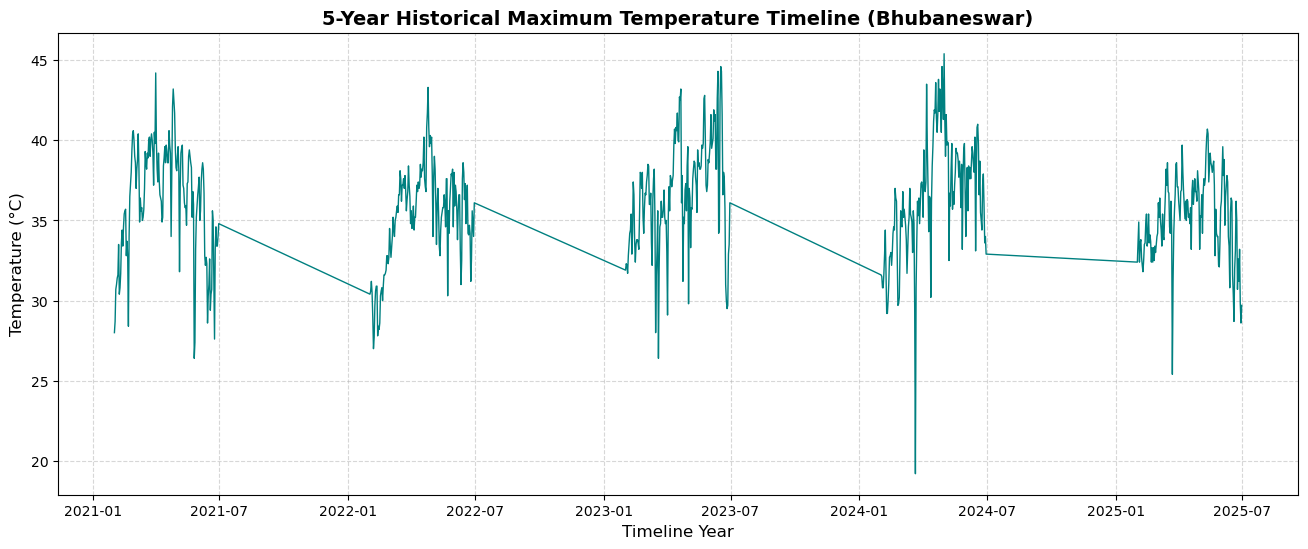

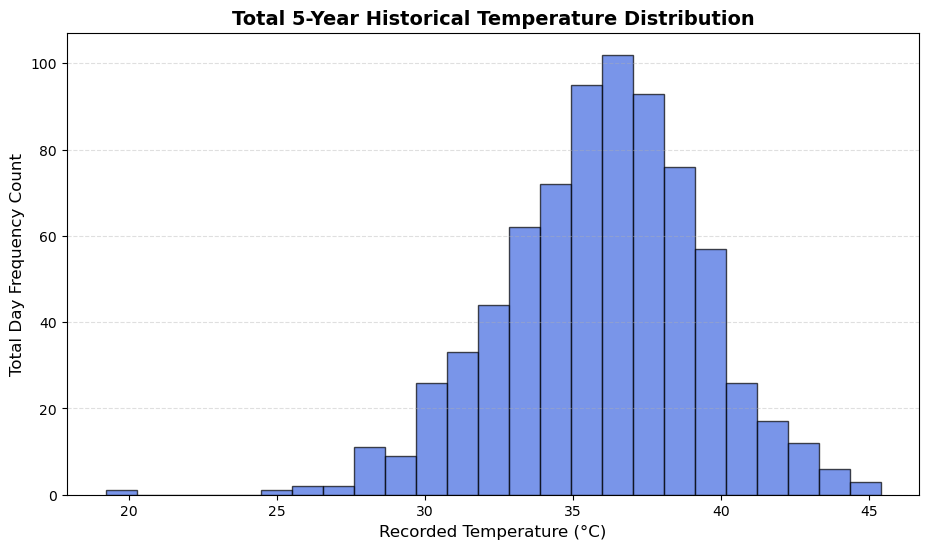

In [8]:

# Configuration based on your sheet's layout structure
excel_file = "MAX TEMP.xlsx"
months_list = ['FEB', 'MAR', 'APR', 'MAY', 'JUN']
month_map = {'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6}

# We will dynamically find where years are, or loop through expected row offsets
# Based on your image, each year block starts roughly 9 rows apart.
# Let's map out the blocks explicitly to ensure accuracy:
year_blocks = [
    {"year": 2025, "skiprows": 1},   # 2025 block starts at the top
    {"year": 2024, "skiprows": 10},  # 2024 block starts around row 11 (skip 10)
    {"year": 2023, "skiprows": 19},  # 2023 block starts around row 20 (skip 19)
    {"year": 2022, "skiprows": 28},  # 2022 block starts around row 29 (skip 28)
    # Add a 5th year block matching your historical file setup if it continues downward:
    {"year": 2021, "skiprows": 37}   
]

all_years_data = []

for block in year_blocks:
    try:
        # Read just the 5 month rows for the specific year block
        df_raw = pd.read_excel(excel_file, skiprows=block["skiprows"], nrows=5)
        
        # Rename the first column containing month strings
        df_raw = df_raw.rename(columns={df_raw.columns[0]: 'Month'})
        
        # Melt the 2D grid (Days 1 to 26+) into a 1D long-form database table
        melted = df_raw.melt(id_vars=['Month'], var_name='Day', value_name='Tmax')
        melted = melted.dropna().copy()
        
        # Convert Day column to pure integers, ignoring string anomalies
        melted['Day'] = pd.to_numeric(melted['Day'], errors='coerce')
        melted = melted.dropna(subset=['Day'])
        melted['Day'] = melted['Day'].astype(int)
        
        # Map month names to numeric values
        melted['Month_Str'] = melted['Month'].str.strip().str.upper()
        melted['Month_Num'] = melted['Month_Str'].map(month_map)
        melted = melted.dropna(subset=['Month_Num'])
        
        # Construct a reliable continuous Datetime index for this block
        melted['Date'] = pd.to_datetime(
            str(block["year"]) + '-' + melted['Month_Num'].astype(int).astype(str) + '-' + melted['Day'].astype(str),
            errors='coerce'
        )
        
        # Drop invalid calendar dates (e.g., Feb 30th) and append
        clean_block = melted.dropna(subset=['Date', 'Tmax'])
        all_years_data.append(clean_block[['Date', 'Tmax']])
        
    except Exception as e:
        print(f"Skipping block for configuration {block['year']} due to formatting shift: {e}")

# Combine all parsed blocks into one comprehensive Master DataFrame
df_master = pd.concat(all_years_data, ignore_index=True).sort_values('Date')

# --- PLOTTING SECTIONS ---

# 1. 5-Year Continuous Time-Series Line Plot
plt.figure(figsize=(16, 6))
plt.plot(df_master['Date'], df_master['Tmax'], color='teal', linewidth=1, label='Daily Max Temp')
plt.title("5-Year Historical Maximum Temperature Timeline (Bhubaneswar)", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Year", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 2. Complete 5-Year Distribution Histogram (For Percentile Calculations)
plt.figure(figsize=(11, 6))
plt.hist(df_master['Tmax'], bins=25, color='royalblue', edgecolor='black', alpha=0.7)
plt.title("Total 5-Year Historical Temperature Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Recorded Temperature (°C)", fontsize=12)
plt.ylabel("Total Day Frequency Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

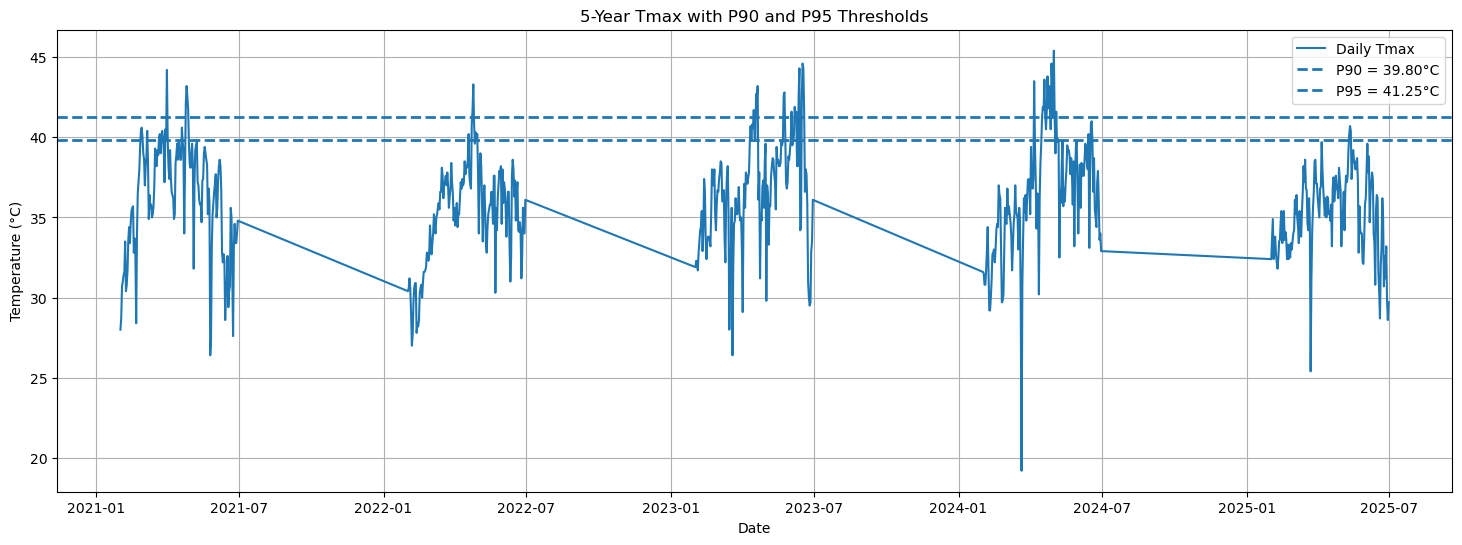

In [9]:
# P90 & P95 Threshold Plot

import numpy as np
import matplotlib.pyplot as plt

p90 = np.percentile(df_master['Tmax'], 90)
p95 = np.percentile(df_master['Tmax'], 95)

plt.figure(figsize=(18,6))

plt.plot(
    df_master['Date'],
    df_master['Tmax'],
    linewidth=1.5,
    label='Daily Tmax'
)

plt.axhline(
    p90,
    linestyle='--',
    linewidth=2,
    label=f'P90 = {p90:.2f}°C'
)

plt.axhline(
    p95,
    linestyle='--',
    linewidth=2,
    label=f'P95 = {p95:.2f}°C'
)

plt.title("5-Year Tmax with P90 and P95 Thresholds")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()

plt.show()

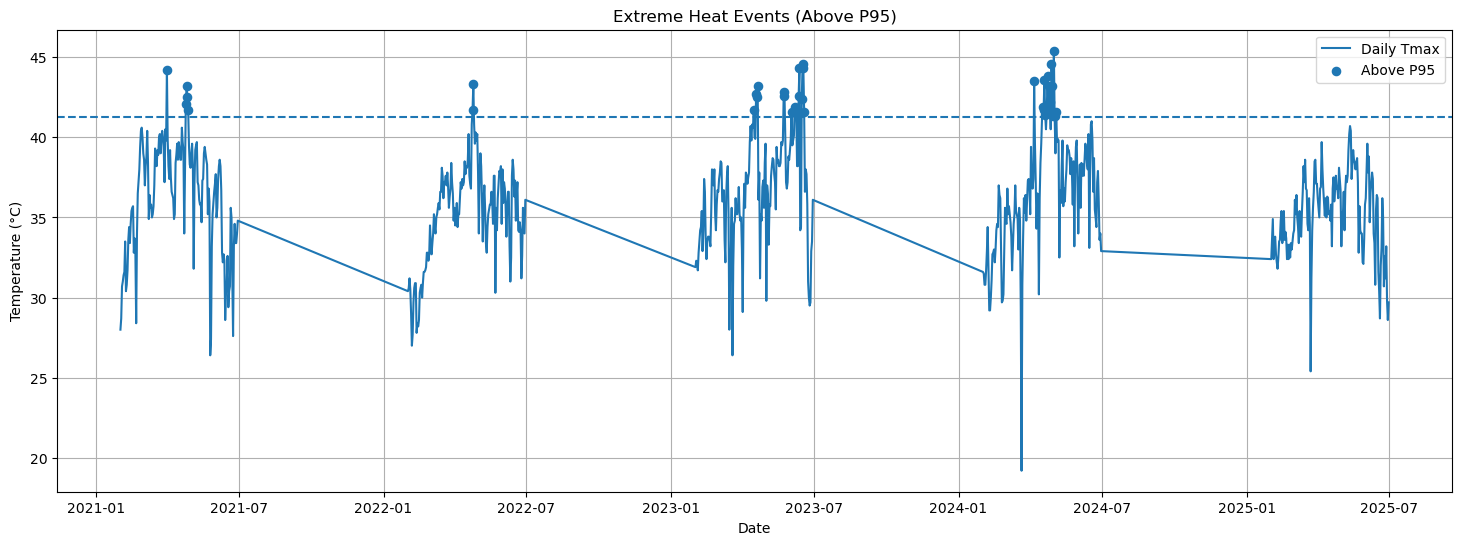

In [10]:
# Highlight Extreme Heat Days

heatwave_days = df_master[
    df_master['Tmax'] >= p95
]

plt.figure(figsize=(18,6))

plt.plot(
    df_master['Date'],
    df_master['Tmax'],
    label='Daily Tmax'
)

plt.scatter(
    heatwave_days['Date'],
    heatwave_days['Tmax'],
    s=35,
    marker='o',
    label='Above P95'
)

plt.axhline(
    p95,
    linestyle='--'
)

plt.title("Extreme Heat Events (Above P95)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.legend()

plt.show()

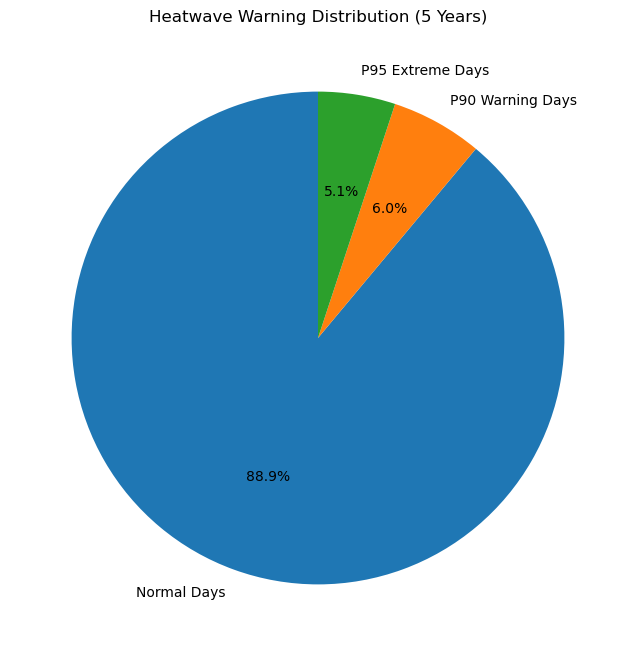

In [11]:
# PIE CHART : Heatwave Warning Distribution
# Calculate Percentiles
p90 = np.percentile(df_master['Tmax'], 90)
p95 = np.percentile(df_master['Tmax'], 95)

# Count Days in Each Category
normal_days = len(df_master[df_master['Tmax'] < p90])

warning_days = len(
    df_master[
        (df_master['Tmax'] >= p90) &
        (df_master['Tmax'] < p95)
    ]
)

extreme_days = len(
    df_master[df_master['Tmax'] >= p95]
)

# Labels and Values
labels = [
    'Normal Days',
    'P90 Warning Days',
    'P95 Extreme Days'
]

sizes = [
    normal_days,
    warning_days,
    extreme_days
]

# Plot Pie Chart
plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Heatwave Warning Distribution (5 Years)")

plt.show()

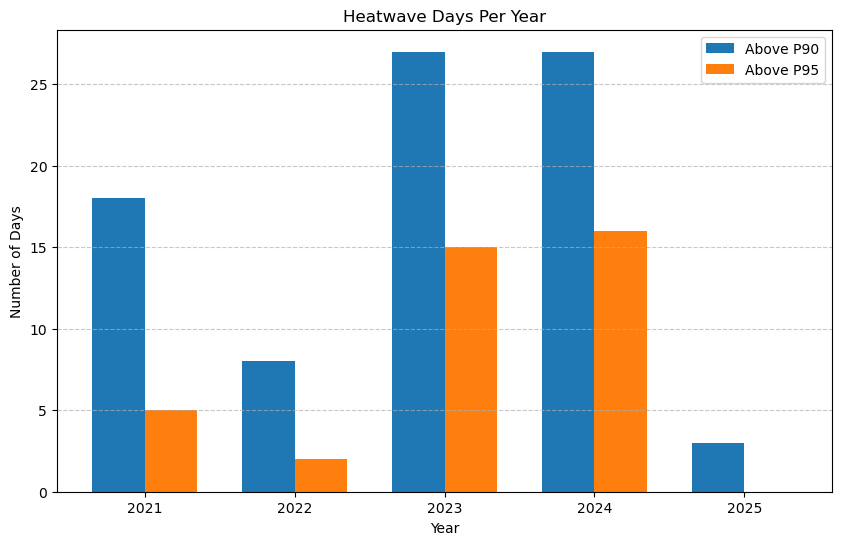

In [12]:
# Heatwave Days Per Year (Fixed)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_master['Year'] = df_master['Date'].dt.year

# Count days above thresholds
p90_days = (
    df_master[df_master['Tmax'] >= p90]
    .groupby('Year')
    .size()
)

p95_days = (
    df_master[df_master['Tmax'] >= p95]
    .groupby('Year')
    .size()
)

# Get all years present
all_years = sorted(df_master['Year'].unique())

# Reindex so missing years become 0
p90_days = p90_days.reindex(all_years, fill_value=0)
p95_days = p95_days.reindex(all_years, fill_value=0)

x = np.arange(len(all_years))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    p90_days.values,
    width,
    label='Above P90'
)

plt.bar(
    x + width/2,
    p95_days.values,
    width,
    label='Above P95'
)

plt.xticks(x, all_years)

plt.title("Heatwave Days Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [13]:
import os

print(os.listdir(r"C:\Users\ASUS\Desktop\IMD"))

['.ipynb_checkpoints', 'MAX TEMP.xlsx', 'MaxTempPlot.ipynb']
